Summary: Introduction to the walkthrough lab on Clustering (K-Means, DBSCAN, HDBSCAN) and Dimensionality Reduction (PCA, t-SNE, UMAP). The goal is to analyze a dataset of 296 Metro Vancouver businesses to help an investor choose a location and category balancing revenue with community impact.

Summary: Section 0 setup guide, recommending installation of specialist libraries `hdbscan` and `umap-learn` before starting.

In [ ]:
# Import core and specialist libraries
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

# Preprocessing, metrics, clustering, PCA, t-SNE, and UMAP
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import hdbscan, umap

# Configure plotting styles and disable warnings
# import warnings
# warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42

print("Setup complete.")

Setup complete.


Summary: Section 1 loading and exploring the GeoJSON business dataset, converting it into a flattened pandas DataFrame for simpler processing.

In [2]:
#open file "business_locations.geojson"
with open("business_locations.geojson") as f:
    #load geojson_data using json parser
    geojson_data = json.load(f)

#print total features count
print("# of features:", len(geojson_data['features']))
#print formatted JSON representation of the first feature
print()
print(json.dumps(geojson_data['features'][0], indent=2))

# of features: 296

{
  "type": "Feature",
  "geometry": {
    "type": "Point",
    "coordinates": [
      -122.78442,
      49.20555
    ]
  },
  "properties": {
    "ID": 1,
    "Neighborhood": "Riverside Commons",
    "Category": "Hospitality",
    "Subcategory": "Theatre",
    "Floor_Area_sqm": 465,
    "Daily_Foot_Traffic": 1995,
    "Community_Impact_Score": 79,
    "Annual_Revenue_k": 1037
  }
}


In [3]:
#Flatten the JSON because right now its a dictionary
#initialize empty list `rows`
rows = []
for feature in geojson_data["features"]:
    props = feature['properties']
    lon, lat = feature['geometry']['coordinates']
#    append properties combined with longitude and latitude to `rows`
    rows.append({**props, "Longtitude": lon, "Latitude": lat})

#for each feature in geojson_data features:
#df = create DataFrame from `rows` with columns: ID, Neighborhood, Category, Subcategory, Longitude, Latitude, Floor_Area_sqm, Daily_Foot_Traffic, Community_Impact_Score, Annual_Revenue_k

df = pd.DataFrame(rows)

#print shape of df
#print first few rows of df

print("shape:", df.shape)
df.head()

shape: (296, 10)


,ID,Neighborhood,Category,Subcategory,Floor_Area_sqm,Daily_Foot_Traffic,Community_Impact_Score,Annual_Revenue_k,Longtitude,Latitude
0,1,Riverside Commons,Hospitality,Theatre,465,1995,79,1037,-122.78442,49.20555
1,2,Riverside Commons,Hospitality,Restaurant,222,1891,66,233,-122.78864,49.20323
2,3,Tech Corridor,Office,Software Firm,596,665,47,3165,-122.91274,49.15874
3,4,Riverside Commons,Hospitality,Theatre,166,1193,92,231,-122.79028,49.20023
4,5,Outer Industrial Park,Industrial,Self-Storage,10460,415,13,4487,-122.70319,49.24512


In [4]:
# print detailed structural information about DataFrame `df` (dtypes, memory, non-nulls)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 296 entries, 0 to 295
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID                      296 non-null    int64  
 1   Neighborhood            296 non-null    str    
 2   Category                296 non-null    str    
 3   Subcategory             296 non-null    str    
 4   Floor_Area_sqm          296 non-null    int64  
 5   Daily_Foot_Traffic      296 non-null    int64  
 6   Community_Impact_Score  296 non-null    int64  
 7   Annual_Revenue_k        296 non-null    int64  
 8   Longtitude              296 non-null    float64
 9   Latitude                296 non-null    float64
dtypes: float64(2), int64(5), str(3)
memory usage: 33.1 KB


In [5]:
# print descriptive statistical summary of DataFrame `df` (mean, std, min, max, etc.)
df.describe()

,ID,Floor_Area_sqm,Daily_Foot_Traffic,Community_Impact_Score,Annual_Revenue_k,Longtitude,Latitude
count,296.000000,296.000000,296.000000,296.000000,296.000000,296.000000,296.000000
mean,148.500000,4396.722973,1106.621622,54.111486,3697.841216,-122.809990,49.195751
std,85.592056,7245.715469,741.744219,26.801551,4652.227233,0.077615,0.031342
min,1.000000,70.000000,15.000000,0.000000,88.000000,-122.966950,49.130680
25%,74.750000,244.750000,422.250000,31.000000,441.000000,-122.878000,49.168255
50%,148.500000,468.500000,815.000000,58.500000,1468.000000,-122.823215,49.189095
75%,222.250000,3287.000000,1777.250000,78.000000,5897.000000,-122.727007,49.217618
max,296.000000,24863.000000,2639.000000,100.000000,33994.000000,-122.651890,49.262650


Summary: Observes scaling differences in raw features (e.g. floor area variance vs. impact score) and introduces visualization of data distribution.

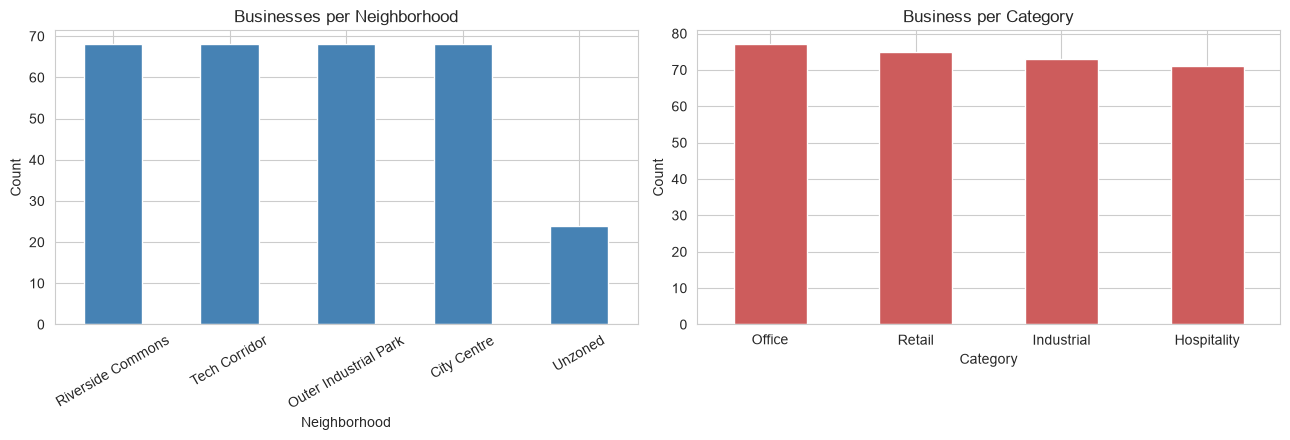

In [6]:
# create subplots with 1 row and 2 columns
fig, axes = plt.subplots(1,2, figsize=(13,4.5))

# plot bar chart of Neighborhood frequency on first subplot
df["Neighborhood"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Businesses per Neighborhood")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=30)

# plot bar chart of Category frequency on second subplot
df["Category"].value_counts().plot(kind="bar", ax=axes[1], color="indianred")
axes[1].set_title("Business per Category")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=0)

# render plots
plt.tight_layout()
plt.show()

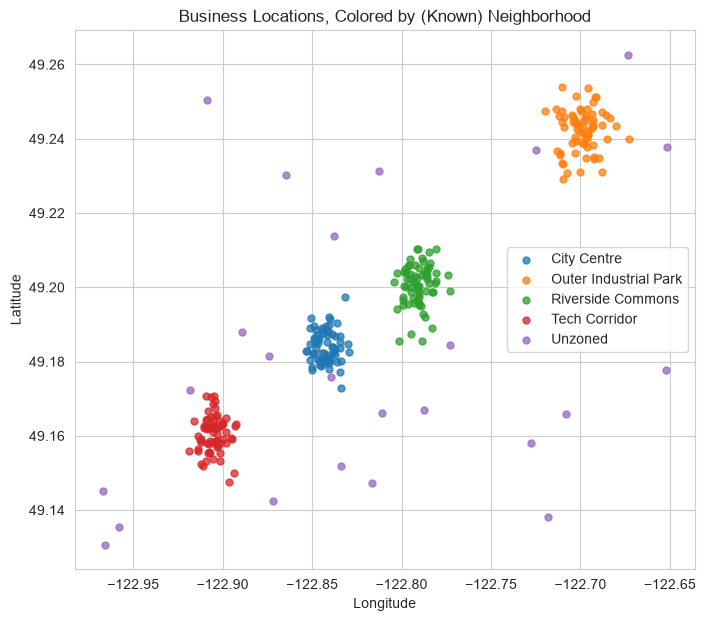

In [7]:
# create scatter plot of Longitude vs Latitude
fig, ax = plt.subplots(figsize=(8,7))

# group data by Neighborhood and color each group differently
for name, group in df.groupby("Neighborhood"):
    ax.scatter(group["Longtitude"], group["Latitude"], label=name, s=25, alpha=0.75)

# add labels, legend, and show plot
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Business Locations, Colored by (Known) Neighborhood")
ax.legend()
plt.show()

Summary: Analyzes ground truth spatial clusters, noting four dense neighborhoods and scattered noise/outlier points.

Summary: Part 1 clustering introduction, explaining unsupervised learning and partitioning coordinate data.

In [8]:
#geo_features = select columns [Longitude, Latitude] from df
geo_features = df[["Longtitude", "Latitude"]].values

#scaler_geo = initialize StandardScaler
scaler_geo = StandardScaler()
#geo_scaled = scale geo_features using fit_transform
geo_scaled = scaler_geo.fit_transform(geo_features)

#print mean and standard deviation of coordinates before and after scaling
print('before, mean was:', geo_features.mean(axis=0), "std was:", geo_features.std(axis=0).round(3))
print('after, mean is:', geo_scaled.mean(axis=0), "std is:", geo_scaled.std(axis=0).round(3))

before, mean was: [-122.80999047   49.19575061] std was: [0.077 0.031]
after, mean is: [-3.59352188e-14  5.75395587e-14] std is: [1. 1.]


Summary: Explains K-Means algorithm steps, characteristics, and limitations in forcing outliers into clusters.

In [9]:
# define function kmeans_step_by_step(X, k, n_iterations, seed):
def kmeans_step_by_step(X, k, n_iterations, seed):
    # initialize random number generator with seed
    rng = np.random.default_rng(seed)
    # randomly select k initial centroids from data points X
    initial_idx = rng.choice(len(X), size=k, replace=False)
    centroids = X[initial_idx].copy()

    # initialize history list with starting centroids
    history = [centroids.copy()]
    labels = None

    # for iteration in range(n_iterations):
    for _ in range(n_iterations):
        # assign each point in X to nearest centroid using Euclidean distance
        distances = np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)
        labels = distances.argmin(axis=1)

        # update each centroid to be the mean of its assigned points
        new_centroids = np.array([
            X[labels == j].mean(axis=0) if np.any(labels == j) else centroids[j]
            for j in range(k)
        ])

        # append new centroids to history list
        centroids = new_centroids
        # return history list and final labels
        history.append(centroids.copy())

    return history, labels

# run kmeans_step_by_step with geo_scaled, k=4, n_iterations=5
centroid_history, manual_labels = kmeans_step_by_step(geo_scaled, k=4, n_iterations=5, seed=0)
# print length of centroid history
print("number of steps in history:", len(centroid_history))

number of steps in history: 6


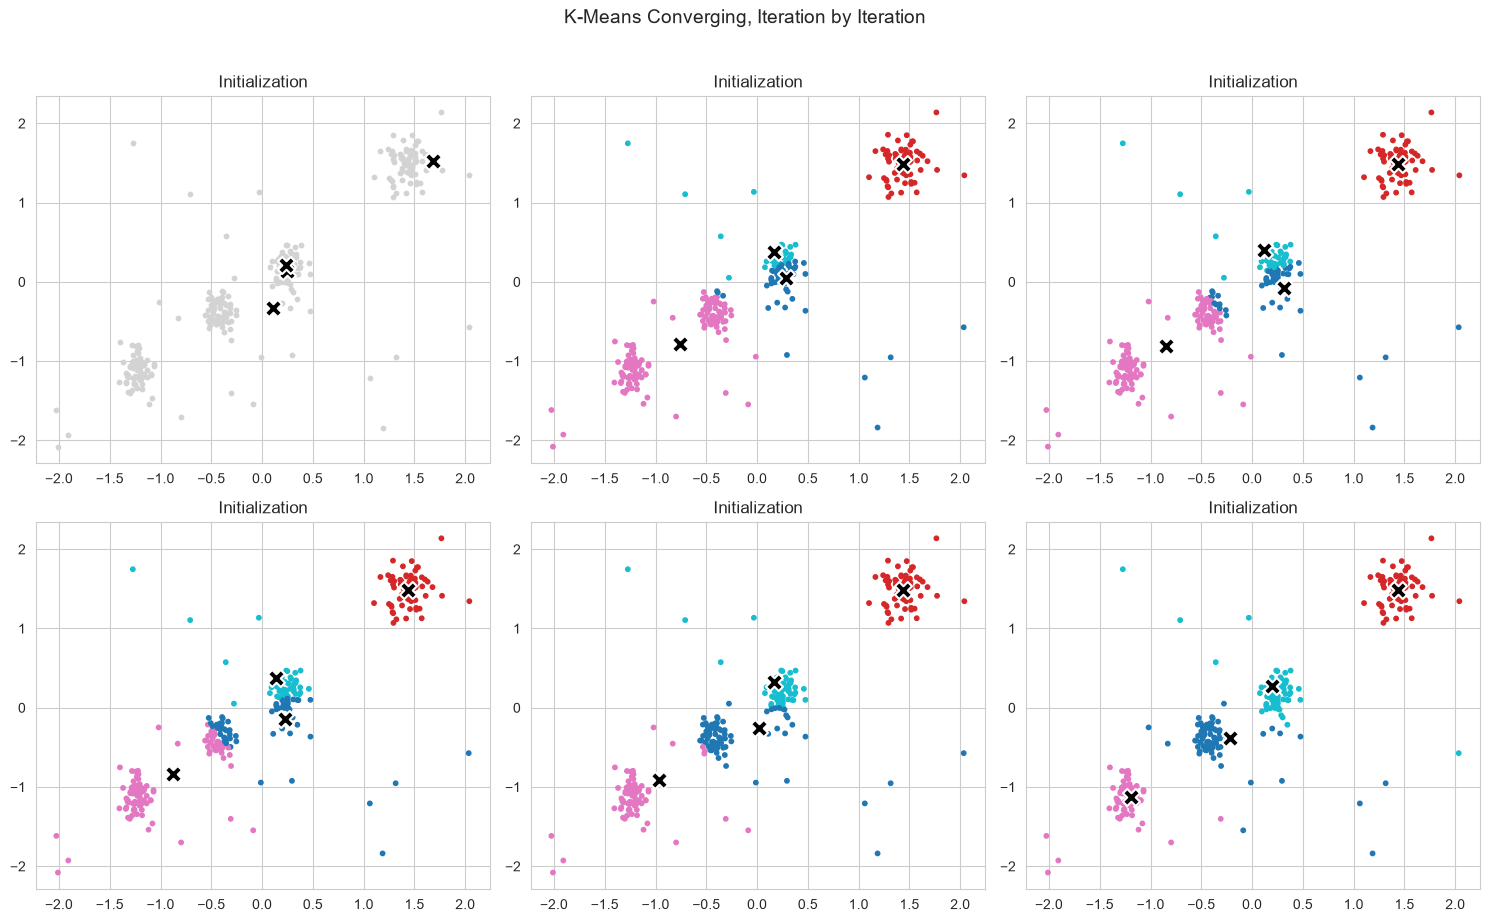

In [10]:
# create 2x3 grid of subplots
fig, axes = plt.subplots(2, 3, figsize=(15,9))
axes = axes.ravel()

# for each subplot:
for i, ax in enumerate(axes):
    centroids = centroid_history[i]
    # if first subplot (initialization):
    if i==0:
        # plot raw unassigned data points and initial centroids
        ax.scatter(geo_scaled[:,0], geo_scaled[:,1], s=10, color="lightgray")
        title="Initialization"
    # else:
    else:
        # assign points to nearest centroids
        distances = np.linalg.norm(geo_scaled[:, None, :] - centroids[None, :, :], axis=2)
        step_labels = distances.argmin(axis=1)
        # plot data points colored by cluster assignment and current centroids
        ax.scatter(geo_scaled[:,0], geo_scaled[:,1], c=step_labels, cmap="tab10", s=10)

    ax.scatter(centroids[:,0], centroids[:,1], c="black", marker="X", s=150, edgecolor="white", linewidth=1.5)
    ax.set_title(title)
    
# show plot
plt.suptitle("K-Means Converging, Iteration by Iteration", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


Summary: Observes K-Means convergence behavior and introduces elbow and silhouette metrics for selecting the cluster count k.

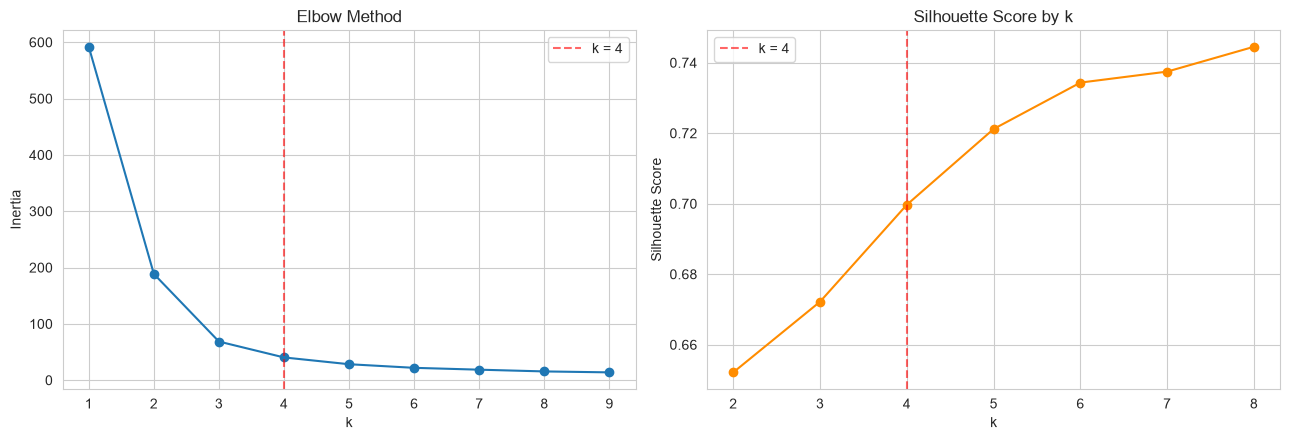

In [11]:
inertias = []
k_range = range(1,10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(geo_scaled)
    inertias.append(km.inertia_)

silhouette_scores = {}
for k in range(2,9):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km_labels = km.fit_predict(geo_scaled)
    silhouette_scores[k] = silhouette_score(geo_scaled, km_labels)

fig, axes = plt.subplots(1,2, figsize=(13, 4.5))

axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method")
axes[0].axvline(4, color="red", linestyle="--", alpha=0.6, label="k = 4")
axes[0].legend()

axes[1].plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), marker="o", color="darkorange")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score by k")
axes[1].axvline(4, color="red", linestyle="--", alpha=0.6, label="k = 4")
axes[1].legend()

plt.tight_layout()
plt.show()

# initialize empty inertias list
# for k in range 1 to 9:
    # fit KMeans with k clusters on geo_scaled
    # append final inertia to inertias list

# initialize empty silhouette_scores dictionary
# for k in range 2 to 8:
    # fit KMeans with k clusters on geo_scaled
    # calculate silhouette score and store in dictionary

# create 1x2 subplot grid
# plot Elbow curve (inertia vs k) on first subplot
# plot Silhouette score vs k on second subplot
# draw optimal line at k=4 on both subplots and show plot

Summary: Evaluates elbow and silhouette diagnostic plots, identifying k=4 as the optimal choice.

In [ ]:
# kmeans_final = fit KMeans with k=4 on geo_scaled
# df[KMeans_Cluster] = predict cluster labels
# plot scatter plot of Longitude vs Latitude colored by KMeans_Cluster
# plot cluster centroids as black 'X' markers and show plot

Summary: Asks how K-Means partitioned unzoned noise points.

In [ ]:
# print cross-tabulation table between KMeans_Cluster and true Neighborhood labels

Summary: Notes K-Means failure in handling noise/outliers, and motivates density-based spatial clustering.

Summary: Explains DBSCAN core/border/noise definitions, algorithm flow, and k-distance plot for choosing eps.

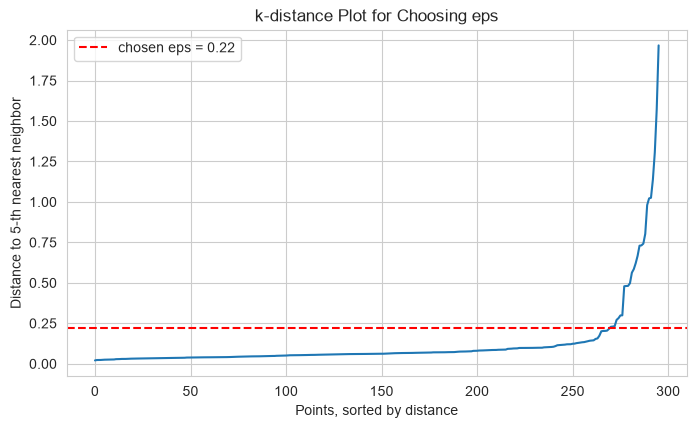

In [12]:
# min_samples = 5
min_samples = 5

# neighbors_model = fit NearestNeighbors with 5 neighbors on geo_scaled
neighbors_model = NearestNeighbors(n_neighbors=min_samples)
neighbors_model.fit(geo_scaled)
# calculate distances of each point to its 5th nearest neighbor
distances, _ = neighbors_model.kneighbors(geo_scaled)

# k_distances = sort distances in ascending order
k_distances = np.sort_complex(distances[:,-1])

# plot sorted k_distances, draw a horizontal line at chosen eps=0.22, and show plot
fig, ax = plt.subplots(figsize=(8,4.5))
ax.plot(k_distances)
ax.axhline(0.22, color="red", linestyle="--", label="chosen eps = 0.22")
ax.set_xlabel("Points, sorted by distance")
ax.set_ylabel(f"Distance to {min_samples}-th nearest neighbor")
ax.set_title("k-distance Plot for Choosing eps")
ax.legend()
plt.show()



Summary: Identifies eps=0.22 at the knee of the k-distance plot.

In [13]:
# dbscan = fit DBSCAN with eps=0.22 and min_samples=5 on geo_scaled
dbscan = DBSCAN(eps=0.22, min_samples=5)
# df[DBSCAN_Cluster] = predict cluster labels
df['DBSCAN_Cluster'] = dbscan.fit_predict(geo_scaled)

n_clusters_dbscan = len(set(df['DBSCAN_Cluster'])) - (1 if -1 in df["DBSCAN_Cluster"].values else 0)
n_noise_dbscan = (df["DBSCAN_Cluster"] == -1).sum()
# print number of clusters found and number of noise points flagged
print(f"number of clusters: {n_clusters_dbscan} and number of noise points: {n_noise_dbscan}")

number of clusters: 4 and number of noise points: 20


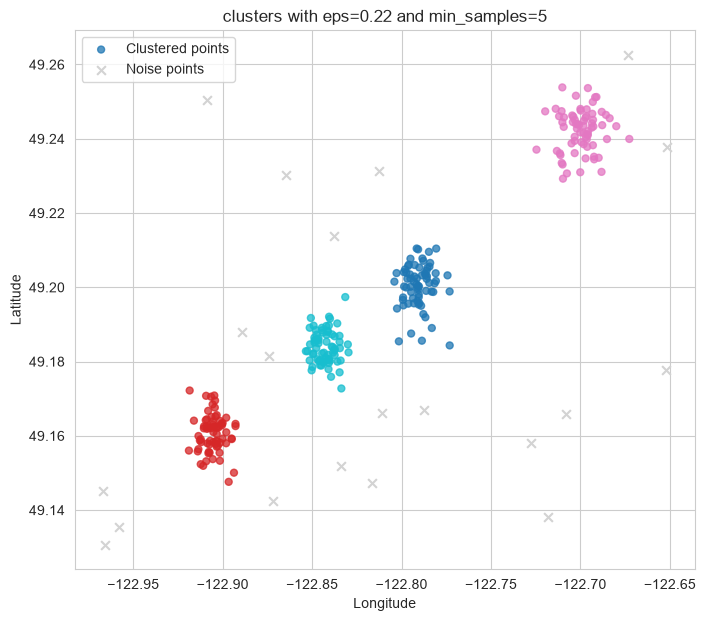

In [14]:
# create scatter plot of Longitude vs Latitude
fig, ax = plt.subplots(figsize=(8,7))

# plot clustered points colored by DBSCAN_Cluster
noise_mask = df['DBSCAN_Cluster'] == -1
ax.scatter(df.loc[~noise_mask, "Longtitude"], df.loc[~noise_mask, "Latitude"],
    c = df.loc[~noise_mask, "DBSCAN_Cluster"], cmap="tab10", s=25, alpha=0.75, label="Clustered points")
# plot noise points (cluster = -1) as light gray 'x' markers and show plot
ax.scatter(df.loc[noise_mask, "Longtitude"], df.loc[noise_mask, "Latitude"],
           c = "lightgray", marker="x", s=40, label="Noise points")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("clusters with eps=0.22 and min_samples=5")
ax.legend()
plt.show()



## End of Lab Code

In [ ]:
# print cross-tabulation table between DBSCAN_Cluster and true Neighborhood labels

Summary: Compares DBSCAN performance to K-Means, highlighting its success with noise but noting uniform density limits. Introduces HDBSCAN.

Summary: Explains HDBSCAN conceptual steps (reachability distance, minimum spanning tree, hierarchy, and condensed tree) which remove the need for a global eps.

In [ ]:
clusterer = fit HDBSCAN with min_cluster_size=10 and min_samples=5 on geo_scaled
df[HDBSCAN_Cluster] = predict cluster labels
df[HDBSCAN_Probability] = save membership probabilities
print number of clusters found and number of noise points flagged

In [ ]:
create scatter plot of Longitude vs Latitude
plot clustered points colored by HDBSCAN_Cluster with alpha set by HDBSCAN_Probability
plot noise points as light gray 'x' markers and show plot

Summary: Explains the condensed tree diagram visualizing cluster splits and branch stability.

In [ ]:
plot HDBSCAN condensed tree highlighting selected clusters and show plot

In [ ]:
print cross-tabulation table between HDBSCAN_Cluster and true Neighborhood labels

Summary: Evaluates HDBSCAN results, showing similar performance to DBSCAN but explaining its advantage for variable densities.

Summary: Provides a comparison table between K-Means, DBSCAN, and HDBSCAN across parameters, noise, shapes, and speed.

In [ ]:
create 1x3 grid of subplots
plot K-Means clusters on first subplot
plot DBSCAN clusters and noise on second subplot
plot HDBSCAN clusters and noise on third subplot
show plot

Summary: Recommends HDBSCAN (with noise filtering) as the most reliable geographic segmentation for the investor.

Summary: Part 2 dimensionality reduction introduction. Highlights the need to compress 4 numeric business attributes into 2 dimensions for visual inspection.

In [ ]:
feature_cols = [Floor_Area_sqm, Daily_Foot_Traffic, Community_Impact_Score, Annual_Revenue_k]
display descriptive statistics (min, max, mean, std) for feature_cols in df

Summary: Discusses scale differences (variance) across features, making standardization a mandatory step to prevent dominating features.

In [ ]:
X_raw = select feature_cols from df as matrix
scaler_features = initialize StandardScaler
X_scaled = scale X_raw using fit_transform
create 1x2 subplot grid
plot variance of features before standardization on first subplot
plot variance of features after standardization on second subplot
show plot

Summary: Notes equalized variance after scaling and introduces PCA.

Summary: Explains PCA mathematical steps (covariance, eigenvalues, sorting, and projection).

In [ ]:
X_pair = select [Floor_Area_sqm, Annual_Revenue_k] from df
X_pair_scaled = scale X_pair using StandardScaler
cov_matrix = calculate covariance matrix of X_pair_scaled
eigenvalues, eigenvectors = calculate eigenvalues and eigenvectors of cov_matrix
sort eigenvalues and eigenvectors in descending order
print covariance matrix, eigenvalues, and eigenvectors

In [ ]:
plot scatter plot of standardized Floor_Area_sqm vs Annual_Revenue_k
draw arrows from origin representing principal components (PC1, PC2) scaled by their eigenvalues
show plot

Summary: Notes that PC1 captures the shared diagonal trend of correlation between floor area and revenue.

In [ ]:
pca = initialize PCA
principal_components = project X_scaled onto principal components
explained = calculate variance explained ratio per component
cumulative = calculate cumulative sum of explained variance
plot scree plot (variance explained per PC and cumulative sum) and show plot
print explained and cumulative variance ratios

Summary: Reviews scree plot showing PC1 and PC2 capture ~89% of the total variance.

In [ ]:
df[PCA1], df[PCA2] = extract first two principal components
plot scatter plot of PCA1 vs PCA2 colored by Category and show plot

Summary: Highlights PCA's superpower of interpretable loading axes.

In [ ]:
loadings = create DataFrame from PCA components with rows as feature_cols and columns as PC1 to PC4
print loadings DataFrame

Summary: Interprets PC1 loading values, showing it models the exact trade-off between scale/revenue and foot-traffic/community impact.

Summary: Explains t-SNE probability maps, t-distribution projection, KL-divergence minimization, and local neighborhood focus.

In [ ]:
create 1x3 grid of subplots
for perplexity in [5, 30, 60]:
    tsne = fit t-SNE with perplexity and PCA initialization on X_scaled
    embedding = project X_scaled to 2D
    plot 2D scatter plot colored by Category
show plot

Summary: Evaluates perplexity parameter influence and notes t-SNE does not preserve global distances.

Summary: Steps of the UMAP algorithm. Explains k-nearest neighbors graph construction, fuzzy simplicial set representation, and low-dimensional projection optimization.

In [ ]:
create 1x3 grid of subplots
for n_neighbors in [5, 15, 40]:
    reducer = fit UMAP with n_neighbors and min_dist=0.1 on X_scaled
    embedding = project X_scaled to 2D
    plot 2D scatter plot colored by Category
show plot

Summary: Discusses UMAP n_neighbors tuning, noting tighter and more cohesive cluster projections compared to t-SNE.

Summary: Compares PCA, t-SNE, and UMAP features, strengths, and output characteristics.

In [ ]:
tsne_best = fit t-SNE with perplexity=30 on X_scaled
umap_best = fit UMAP with n_neighbors=15 on X_scaled
create 1x3 grid of subplots
plot PCA projection on first subplot
plot t-SNE projection on second subplot
plot UMAP projection on third subplot
color all plots by Category and show plot

Summary: Reviews side-by-side projections, comparing linear and non-linear properties in separating business categories.

Summary: Part 3 introduction. Combines spatial segments (HDBSCAN) with business attributes (PCA) for neighborhood profiling, dropping noise first.

In [ ]:
clean_df = filter df to exclude noise points (HDBSCAN_Cluster != -1)
print count of dropped noise points and remaining points
neighborhood_profile = group clean_df by Neighborhood and calculate mean of numeric columns
sort profile by avg_community_impact descending and print it

In [ ]:
plot scatter plot of Community_Impact_Score vs Annual_Revenue_k (log scale) grouped by Neighborhood
show plot

Summary: Profiles neighborhoods based on community impact vs. revenue trade-off, recommending Retail in City Centre or Tech Corridor office locations.

Summary: Concludes the lab, summarizing findings on spatial clustering and dimensionality reduction methods. Lists practice questions.